
# Circular mitochondrial genome mapping and reference-guided assembly

This notebook has been minimally adjusted for the folder layout shown in your screenshot:

1. Uses `Locusta migratoria_mt` as the mitochondrial reference sequence. The file may be named `Locusta migratoria_mt`, `Locusta migratoria_mt.fasta`, `.fa`, `.fas`, or `.fna`.
2. Reads input files `1`–`15`. The files may be plain text/FASTA files with or without `.txt` extensions.
3. Removes duplicate records by sequence ID, keeping the first occurrence.
4. Maps reads to the circular mitochondrial reference, allowing imperfect similarity for other-species analysis.
5. Calculates coverage/depth and writes summary outputs.
6. Builds a draft reference-guided mitochondrial consensus assembly from mapped, overlapping reads.

Notes:
- Deduplication is by sequence ID, not by sequence string.
- Mapping tries forward and reverse-complement orientations.
- Mapping order is: exact circular match → relaxed Hamming-distance match → local-alignment rescue.
- Because this is other-species/reference-guided assembly, the local-alignment identity cutoff is relaxed in the settings cell below. Increase it if too many weak/off-target reads map.


In [46]:

from pathlib import Path
from collections import defaultdict, Counter, OrderedDict
import re, statistics, json, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio import pairwise2


In [47]:

BASE = Path('.')

# Reference and read files in the same folder as this notebook.
# These names match the screenshot. Common extensions are resolved automatically.
REFERENCE_STEM = 'Mus_spretus_mt'
READ_FILE_STEMS = [str(i) for i in range(1, 20)]
FILE_SUFFIXES = ['', '.txt', '.fasta', '.fa', '.fas', '.fna']

def resolve_existing_file(base, stem, suffixes=FILE_SUFFIXES):
    """Find a file by stem, allowing common text/FASTA suffixes and case-insensitive matches."""
    base = Path(base)
    candidates = []
    for suffix in suffixes:
        p = base / f"{stem}{suffix}"
        if p not in candidates:
            candidates.append(p)

    for p in candidates:
        if p.exists():
            return p

    # Windows users often see names without extensions. This fallback helps when case differs.
    if base.exists():
        by_lower_name = {p.name.lower(): p for p in base.iterdir() if p.is_file()}
        for p in candidates:
            hit = by_lower_name.get(p.name.lower())
            if hit is not None:
                return hit

    tried = ', '.join(str(p) for p in candidates)
    raise FileNotFoundError(f"Could not find {stem!r}. Tried: {tried}")

REFERENCE_FILE = resolve_existing_file(BASE, REFERENCE_STEM)
READ_FILES = [resolve_existing_file(BASE, stem) for stem in READ_FILE_STEMS]

# Relaxed settings for other-species/reference-guided mitochondrial mapping.
# If too many weak/off-target reads map, raise LOCAL_IDENTITY_MIN to 0.85 or 0.90.
HAMMING_MAX_MISMATCHES = 8
LOCAL_SEED_K = 10
LOCAL_SEED_STEP = 5
LOCAL_TOP_CANDIDATES = 60
LOCAL_ALIGNMENT_EXTRA_BP = 40
LOCAL_IDENTITY_MIN = 0.80
LOCAL_MIN_QUERY_COVERAGE = 0.75

OUTPUT_CSV = BASE / 'final_circular_dedup_by_id_mapping_results.csv'
OUTPUT_SUMMARY = BASE / 'final_circular_dedup_by_id_mapping_summary.txt'
OUTPUT_PLOT = BASE / 'final_circular_dedup_by_id_coverage_plot.png'
OUTPUT_CONSENSUS = BASE / 'reference_guided_mt_consensus.fasta'
OUTPUT_CONSENSUS_TABLE = BASE / 'reference_guided_mt_consensus_base_counts.csv'

print('Reference file:', REFERENCE_FILE)
print('Read files:')
for p in READ_FILES:
    print(' -', p)


Reference file: Mus_spretus_mt.fasta
Read files:
 - 1.txt
 - 2.txt
 - 3.txt
 - 4.txt
 - 5.txt
 - 6.txt
 - 7.txt
 - 8.txt
 - 9.txt
 - 10.txt
 - 11.txt
 - 12.txt
 - 13.txt
 - 14.txt
 - 15.txt
 - 16.txt
 - 17.txt
 - 18.txt
 - 19.txt


In [48]:

def parse_fasta(path):
    """Parse FASTA. If a text file has no FASTA headers, treat each non-empty line as one read."""
    path = Path(path)
    lines = [line.strip() for line in path.read_text().splitlines() if line.strip()]
    if not lines:
        return []

    # Plain text fallback: one sequence per non-empty line.
    if not any(line.startswith('>') for line in lines):
        records = []
        for i, line in enumerate(lines, start=1):
            seq = re.sub(r'[^A-Za-z]', '', line).upper()
            if seq:
                records.append((f'{path.stem}_{i}', seq))
        return records

    records = []
    seq_id = None
    seq_chunks = []
    for line in lines:
        if line.startswith('>'):
            if seq_id is not None:
                records.append((seq_id, ''.join(seq_chunks).upper()))
            seq_id = line[1:].strip()
            seq_chunks = []
        else:
            seq_chunks.append(re.sub(r'[^A-Za-z]', '', line))
    if seq_id is not None:
        records.append((seq_id, ''.join(seq_chunks).upper()))
    return records

def revcomp(seq):
    table = str.maketrans(
        'ACGTRYKMSWBDHVNacgtrykmswbdhvn',
        'TGCAYRMKSWVHDBNtgcayrmkswvhdbn',
    )
    return seq.translate(table)[::-1].upper()

def build_index(seq, k):
    idx = defaultdict(list)
    if k < 1 or k > len(seq):
        return idx
    for i in range(len(seq) - k + 1):
        kmer = seq[i:i+k]
        if 'N' not in kmer:
            idx[kmer].append(i)
    return idx

def mismatches(a, b, max_mm=None):
    mm = 0
    for x, y in zip(a, b):
        if x != y:
            mm += 1
            if max_mm is not None and mm > max_mm:
                return mm
    return mm


In [49]:

reference_records = parse_fasta(REFERENCE_FILE)
assert len(reference_records) == 1, f"Expected exactly one reference sequence in {REFERENCE_FILE}, found {len(reference_records)}"
reference_id, reference_seq = reference_records[0]
reference_seq = reference_seq.upper()
reference_len = len(reference_seq)
reference_circular = reference_seq + reference_seq

total_input_records = 0
unique_by_id = {}
duplicate_records_removed = Counter()
different_sequence_duplicate_ids = []
source_map = defaultdict(list)

for read_file in READ_FILES:
    records = parse_fasta(read_file)
    total_input_records += len(records)
    for full_header, seq in records:
        seq = seq.upper()
        short_id = full_header.split()[0]
        source_map[short_id].append(read_file.name)
        if short_id not in unique_by_id:
            unique_by_id[short_id] = {
                'full_header': full_header,
                'sequence': seq,
                'source_first_seen': read_file.name,
            }
        else:
            duplicate_records_removed[short_id] += 1
            if unique_by_id[short_id]['sequence'] != seq:
                different_sequence_duplicate_ids.append(short_id)

print('Reference ID:', reference_id)
print('Reference length:', reference_len)
print('Total input records:', total_input_records)
print('Unique sequence IDs:', len(unique_by_id))
print('Duplicate records removed by ID:', sum(duplicate_records_removed.values()))
if different_sequence_duplicate_ids:
    print('Warning: duplicate IDs with different sequences were found; kept the first occurrence for each ID.')
    print('Example IDs:', sorted(set(different_sequence_duplicate_ids))[:10])


Reference ID: KY018921.1 Mus spretus mitochondrion, complete genome
Reference length: 16304
Total input records: 7836
Unique sequence IDs: 6529
Duplicate records removed by ID: 1307


In [50]:

index_by_len = {}

def get_index(k):
    k = int(k)
    if k not in index_by_len:
        index_by_len[k] = build_index(reference_circular, k)
    return index_by_len[k]

def split_query_into_blocks(query_len, n_blocks, min_seed_len=8):
    n_blocks = max(1, min(n_blocks, query_len))
    cuts = [round(i * query_len / n_blocks) for i in range(n_blocks + 1)]
    blocks = []
    for a, b in zip(cuts, cuts[1:]):
        if b > a and (b - a) >= min_seed_len:
            blocks.append((a, b))
    return blocks

def circular_exact_start(query):
    pos = reference_circular.find(query, 0, reference_len + len(query) - 1)
    return None if pos == -1 else pos % reference_len

def circular_hamming_map(query, max_mm=HAMMING_MAX_MISMATCHES):
    exact = circular_exact_start(query)
    if exact is not None:
        return exact, 0

    # Pigeonhole seeding: if a read has <= k mismatches, one of k+1 blocks should match exactly.
    for allowed_mm in range(1, max_mm + 1):
        candidates = set()
        for a, b in split_query_into_blocks(len(query), allowed_mm + 1, min_seed_len=8):
            seed = query[a:b]
            if 'N' in seed:
                continue
            for p in get_index(len(seed)).get(seed, []):
                candidates.add((p - a) % reference_len)

        best = None
        for start in candidates:
            target = reference_circular[start:start + len(query)]
            mm = mismatches(query, target, allowed_mm)
            if mm <= allowed_mm:
                if best is None or mm < best[1] or (mm == best[1] and start < best[0]):
                    best = (start, mm)

        if best is not None:
            return best

    return None

def candidate_starts_from_seeds(query, step=LOCAL_SEED_STEP, k=LOCAL_SEED_K):
    counter = Counter()
    seed_sizes = [k]
    if k > 8:
        seed_sizes.append(8)
    if min(seed_sizes) > 6:
        seed_sizes.append(6)

    for seed_k in seed_sizes:
        if len(query) < seed_k:
            continue
        for offset in range(0, len(query) - seed_k + 1, step):
            seed = query[offset:offset + seed_k]
            if 'N' in seed:
                continue
            for p in get_index(seed_k).get(seed, []):
                counter[(p - offset) % reference_len] += 1
        if counter:
            break

    return [start for start, _ in counter.most_common(LOCAL_TOP_CANDIDATES)]

def local_alignment_stats(aligned_ref, aligned_query, begin, end):
    ref_pos = sum(1 for c in aligned_ref[:begin] if c != '-')
    first_ref = None
    matches = mism = gaps = aligned_query_bases = 0

    for ca, cb in zip(aligned_ref[begin:end], aligned_query[begin:end]):
        if cb != '-':
            aligned_query_bases += 1
        if ca != '-' and cb != '-':
            if first_ref is None:
                first_ref = ref_pos
            if ca == cb:
                matches += 1
            else:
                mism += 1
        elif ca == '-' and cb != '-':
            gaps += 1
        elif ca != '-' and cb == '-':
            gaps += 1
        if ca != '-':
            ref_pos += 1

    identity = matches / max(1, matches + mism + gaps)
    return first_ref, matches, mism, gaps, aligned_query_bases, identity

def circular_local_map(query):
    best = None
    best_rank = None
    for orientation, q in [('forward', query), ('reverse', revcomp(query))]:
        starts = candidate_starts_from_seeds(q)
        for start in starts:
            window = reference_circular[start:start + len(q) + LOCAL_ALIGNMENT_EXTRA_BP]
            alns = pairwise2.align.localms(window, q, 2, -1, -2, -0.5, one_alignment_only=True)
            if not alns:
                continue

            aligned_ref, aligned_query, score, begin, end = alns[0]
            first_ref, matches, mism, gaps, aligned_query_bases, identity = local_alignment_stats(
                aligned_ref, aligned_query, begin, end
            )
            if first_ref is None:
                continue

            query_coverage = aligned_query_bases / max(1, len(q))
            if identity < LOCAL_IDENTITY_MIN or query_coverage < LOCAL_MIN_QUERY_COVERAGE:
                continue

            mapped_start = (start + first_ref) % reference_len
            rank = (score, identity, query_coverage, -mism, -gaps)
            candidate = (mapped_start, orientation, mism, gaps, score, identity, query_coverage)
            if best is None or rank > best_rank:
                best = candidate
                best_rank = rank

    return best


In [51]:

results = []

for seq_id, rec in unique_by_id.items():
    seq = rec['sequence']
    best = None

    for orientation, q in [('forward', seq), ('reverse', revcomp(seq))]:
        hm = circular_hamming_map(q, max_mm=HAMMING_MAX_MISMATCHES)
        if hm is not None:
            start, mm = hm
            method = 'circular_exact' if mm == 0 else f'circular_hamming_{mm}mm'
            candidate = (mm, start, orientation, method, q)
            if best is None or candidate < best:
                best = candidate

    if best is None:
        local = circular_local_map(seq)
        if local is not None:
            start, orientation, mism, gaps, score, identity, query_coverage = local
            q = seq if orientation == 'forward' else revcomp(seq)
            results.append({
                'seq_id': seq_id,
                'full_header': rec['full_header'],
                'source_first_seen': rec['source_first_seen'],
                'duplicate_instances_removed': duplicate_records_removed.get(seq_id, 0),
                'length': len(seq),
                'orientation': orientation,
                'start_1based': start + 1,
                'end_1based_circular': ((start + len(q) - 1) % reference_len) + 1,
                'method': 'circular_local',
                'mismatches': mism,
                'gaps_est': gaps,
                'local_score': score,
                'identity_est': identity,
                'query_coverage_est': query_coverage,
                'sequence': seq,
            })
        else:
            results.append({
                'seq_id': seq_id,
                'full_header': rec['full_header'],
                'source_first_seen': rec['source_first_seen'],
                'duplicate_instances_removed': duplicate_records_removed.get(seq_id, 0),
                'length': len(seq),
                'orientation': '',
                'start_1based': '',
                'end_1based_circular': '',
                'method': 'unmapped',
                'mismatches': '',
                'gaps_est': '',
                'local_score': '',
                'identity_est': '',
                'query_coverage_est': '',
                'sequence': seq,
            })
    else:
        mm, start, orientation, method, q = best
        results.append({
            'seq_id': seq_id,
            'full_header': rec['full_header'],
            'source_first_seen': rec['source_first_seen'],
            'duplicate_instances_removed': duplicate_records_removed.get(seq_id, 0),
            'length': len(seq),
            'orientation': orientation,
            'start_1based': start + 1,
            'end_1based_circular': ((start + len(q) - 1) % reference_len) + 1,
            'method': method,
            'mismatches': mm,
            'gaps_est': 0,
            'local_score': '',
            'identity_est': 1 - mm / len(q),
            'query_coverage_est': 1.0,
            'sequence': seq,
        })

mapping_df = pd.DataFrame(results)
mapping_df.head()


,seq_id,full_header,source_first_seen,duplicate_instances_removed,length,orientation,start_1based,end_1based_circular,method,mismatches,gaps_est,local_score,identity_est,query_coverage_est,sequence
0,gnl|SRA|ERR1124353.415381560.1,gnl|SRA|ERR1124353.415381560.1 HWI-ST731:80:C3...,1.txt,0,101,reverse,611,711,circular_exact,0,0,,1.0,1.0,ACCTTTTTAGGGTTTGCTGAAGATGGCGGTATATAGGCTGAATTAG...
1,gnl|SRA|ERR1124353.413292480.2,gnl|SRA|ERR1124353.413292480.2 HWI-ST731:80:C3...,1.txt,0,101,reverse,619,719,circular_exact,0,0,,1.0,1.0,ACTTTAATACCTTTTTAGGGTTTGCTGAAGATGGCGGTATATAGGC...
2,gnl|SRA|ERR1124353.412297666.2,gnl|SRA|ERR1124353.412297666.2 HWI-ST731:80:C3...,1.txt,1,101,reverse,243,343,circular_exact,0,0,,1.0,1.0,ATTAGTTTGGGTTAATCGTATGACCGCGGTGGCTGGCACGAAATTT...
3,gnl|SRA|ERR1124353.410762809.1,gnl|SRA|ERR1124353.410762809.1 HWI-ST731:80:C3...,1.txt,1,101,reverse,245,345,circular_exact,0,0,,1.0,1.0,TAATTAGTTTGGGTTAATCGTATGACCGCGGTGGCTGGCACGAAAT...
4,gnl|SRA|ERR1124353.410145942.2,gnl|SRA|ERR1124353.410145942.2 HWI-ST731:80:C3...,1.txt,1,101,forward,235,335,circular_exact,0,0,,1.0,1.0,CAGCAGTGATAAATATTAAGCAATAAACGAAAGTTTGACTAAGTTA...


In [52]:

depth = np.zeros(reference_len, dtype=int)

for row in mapping_df.itertuples(index=False):
    if row.method == 'unmapped':
        continue
    start0 = int(row.start_1based) - 1
    for j in range(int(row.length)):
        depth[(start0 + j) % reference_len] += 1

covered_bp = int((depth > 0).sum())

zero_intervals = []
i = 0
while i < reference_len:
    if depth[i] == 0:
        j = i
        while j < reference_len and depth[j] == 0:
            j += 1
        zero_intervals.append((i + 1, j))
        i = j
    else:
        i += 1

sequence_counts = Counter(rec['sequence'] for rec in unique_by_id.values())
sequence_level_duplicate_total = sum(c - 1 for c in sequence_counts.values() if c > 1)
shared_sequence_string_count = sum(1 for c in sequence_counts.values() if c > 1)

summary = {
    'reference_length_bp': reference_len,
    'total_input_records': total_input_records,
    'unique_sequence_ids_after_dedup': len(unique_by_id),
    'duplicate_records_removed_by_id': int(sum(duplicate_records_removed.values())),
    'mapped_unique_ids': int((mapping_df['method'] != 'unmapped').sum()),
    'unmapped_unique_ids': int((mapping_df['method'] == 'unmapped').sum()),
    'circular_coverage_bp': covered_bp,
    'circular_coverage_percent': round(covered_bp / reference_len * 100, 4),
    'minimum_depth_unique_ids': int(depth.min()),
    'mean_depth_unique_ids': round(float(depth.mean()), 4),
    'maximum_depth_unique_ids': int(depth.max()),
    'zero_coverage_intervals_1based': zero_intervals,
    'mapping_method_counts': dict(Counter(mapping_df['method'])),
    'orientation_counts_mapped': dict(Counter(mapping_df.loc[mapping_df['method'] != 'unmapped', 'orientation'])),
    'unique_sequence_strings_among_unique_ids': len(sequence_counts),
    'extra_duplicate_sequences_by_content_among_unique_ids': int(sequence_level_duplicate_total),
    'number_of_sequence_strings_shared_by_multiple_unique_ids': int(shared_sequence_string_count),
    'hamming_max_mismatches': HAMMING_MAX_MISMATCHES,
    'local_identity_min': LOCAL_IDENTITY_MIN,
    'local_min_query_coverage': LOCAL_MIN_QUERY_COVERAGE,
}
summary


{'reference_length_bp': 16304,
 'total_input_records': 7836,
 'unique_sequence_ids_after_dedup': 6529,
 'duplicate_records_removed_by_id': 1307,
 'mapped_unique_ids': 6529,
 'unmapped_unique_ids': 0,
 'circular_coverage_bp': 16304,
 'circular_coverage_percent': 100.0,
 'minimum_depth_unique_ids': 10,
 'mean_depth_unique_ids': 40.4458,
 'maximum_depth_unique_ids': 95,
 'zero_coverage_intervals_1based': [],
 'mapping_method_counts': {'circular_exact': 5053,
  'circular_hamming_1mm': 857,
  'circular_local': 312,
  'circular_hamming_2mm': 113,
  'circular_hamming_3mm': 29,
  'circular_hamming_7mm': 38,
  'circular_hamming_4mm': 29,
  'circular_hamming_5mm': 18,
  'circular_hamming_8mm': 49,
  'circular_hamming_6mm': 31},
 'orientation_counts_mapped': {'reverse': 3230, 'forward': 3299},
 'unique_sequence_strings_among_unique_ids': 3974,
 'extra_duplicate_sequences_by_content_among_unique_ids': 2555,
 'number_of_sequence_strings_shared_by_multiple_unique_ids': 1238,
 'hamming_max_mismatches

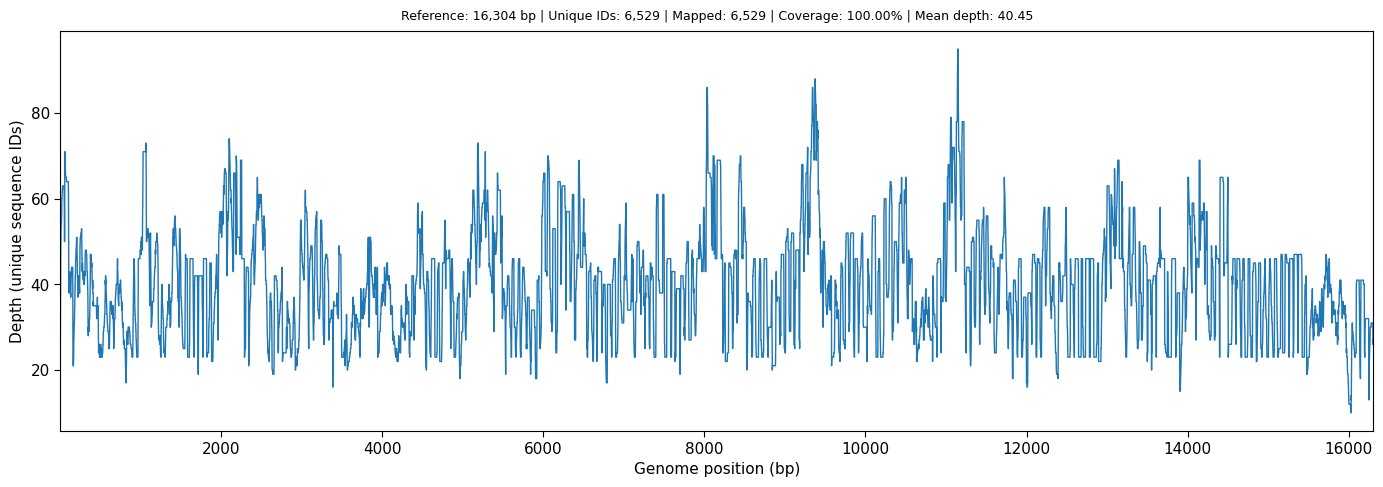

Wrote:
 - final_circular_dedup_by_id_mapping_results.csv
 - final_circular_dedup_by_id_mapping_summary.txt
 - final_circular_dedup_by_id_coverage_plot.png
Consensus will be written by the next cell: reference_guided_mt_consensus.fasta


In [53]:

mapping_df.to_csv(OUTPUT_CSV, index=False)

with open(OUTPUT_SUMMARY, 'w') as handle:
    for key, value in summary.items():
        handle.write(f"{key}: {value}\n")

plt.figure(figsize=(14, 5))
plt.plot(np.arange(1, reference_len + 1), depth, linewidth=1)
#plt.title('Circular mitochondrial genome coverage depth after deduplication by sequence ID')
plt.xlabel('Genome position (bp)')
plt.ylabel('Depth (unique sequence IDs)')
plt.xlim(1, reference_len)
plt.text(
    0.5,
    1.02,
    f"Reference: {reference_len:,} bp | Unique IDs: {len(unique_by_id):,} | "
    f"Mapped: {(mapping_df['method'] != 'unmapped').sum():,} | "
    f"Coverage: {covered_bp / reference_len * 100:.2f}% | "
    f"Mean depth: {depth.mean():.2f}",
    transform=plt.gca().transAxes,
    ha='center',
    va='bottom',
    fontsize=9,
)
plt.tight_layout()
plt.savefig(OUTPUT_PLOT, dpi=200, bbox_inches='tight')
plt.show()

print("Wrote:")
print(" -", OUTPUT_CSV)
print(" -", OUTPUT_SUMMARY)
print(" -", OUTPUT_PLOT)
print("Consensus will be written by the next cell:", OUTPUT_CONSENSUS)


In [54]:

# Draft reference-guided mitochondrial consensus assembly from mapped, overlapping reads.
# Positions with no mapped read support are written as N.

base_counts = [Counter() for _ in range(reference_len)]

def add_direct_read_to_counts(q, start0):
    for j, base in enumerate(q):
        if base in 'ACGT':
            base_counts[(start0 + j) % reference_len][base] += 1

def add_local_read_to_counts(q, start0):
    # Re-align local reads near their mapped start so indels do not shift the consensus counts.
    window = reference_circular[start0:start0 + len(q) + LOCAL_ALIGNMENT_EXTRA_BP]
    alns = pairwise2.align.localms(window, q, 2, -1, -2, -0.5, one_alignment_only=True)
    if not alns:
        add_direct_read_to_counts(q, start0)
        return

    aligned_ref, aligned_query, score, begin, end = alns[0]
    ref_pos = sum(1 for c in aligned_ref[:begin] if c != '-')
    for ca, cb in zip(aligned_ref[begin:end], aligned_query[begin:end]):
        if ca != '-' and cb != '-' and cb in 'ACGT':
            base_counts[(start0 + ref_pos) % reference_len][cb] += 1
        if ca != '-':
            ref_pos += 1

for row in mapping_df.itertuples(index=False):
    if row.method == 'unmapped':
        continue
    seq = unique_by_id[row.seq_id]['sequence']
    q = seq if row.orientation == 'forward' else revcomp(seq)
    start0 = int(row.start_1based) - 1
    if row.method == 'circular_local':
        add_local_read_to_counts(q, start0)
    else:
        add_direct_read_to_counts(q, start0)

consensus_bases = []
consensus_rows = []
for i, counts in enumerate(base_counts):
    total = sum(counts.values())
    if total == 0:
        base = 'N'
    else:
        max_count = max(counts.values())
        tied = sorted([b for b, c in counts.items() if c == max_count])
        # Prefer the reference base only as a tie-breaker, not as read evidence.
        base = reference_seq[i] if reference_seq[i] in tied else tied[0]

    consensus_bases.append(base)
    consensus_rows.append({
        'position_1based': i + 1,
        'reference_base': reference_seq[i],
        'consensus_base': base,
        'depth': total,
        'A': counts.get('A', 0),
        'C': counts.get('C', 0),
        'G': counts.get('G', 0),
        'T': counts.get('T', 0),
    })

consensus_seq = ''.join(consensus_bases)
covered_consensus_bp = sum(1 for b in consensus_seq if b != 'N')

with open(OUTPUT_CONSENSUS, 'w') as handle:
    header = (
        f">reference_guided_mt_consensus length={reference_len} "
        f"covered_bp={covered_consensus_bp} reference={reference_id}\n"
    )
    handle.write(header)
    for i in range(0, len(consensus_seq), 80):
        handle.write(consensus_seq[i:i + 80] + '\n')

pd.DataFrame(consensus_rows).to_csv(OUTPUT_CONSENSUS_TABLE, index=False)

print(f"Wrote draft consensus assembly: {OUTPUT_CONSENSUS}")
print(f"Wrote base-count table: {OUTPUT_CONSENSUS_TABLE}")
print(f"Consensus covered bp: {covered_consensus_bp:,} / {reference_len:,} ({covered_consensus_bp / reference_len * 100:.2f}%)")


Wrote draft consensus assembly: reference_guided_mt_consensus.fasta
Wrote base-count table: reference_guided_mt_consensus_base_counts.csv
Consensus covered bp: 16,303 / 16,304 (99.99%)


In [55]:

# Merge the same read files used in the workflow and deduplicate by sequence ID.
input_files = READ_FILES
output_fasta = BASE / 'merged_reads_deduplicated_by_id.fasta'

all_records = []
for f in input_files:
    recs = parse_fasta(f)
    print(f"{Path(f).name}: {len(recs)} records")
    all_records.extend(recs)

total_input_records_merged = len(all_records)

unique_by_id_merged = OrderedDict()
duplicate_count_merged = 0

for full_header, seq in all_records:
    seq_id = full_header.split()[0]
    if seq_id not in unique_by_id_merged:
        unique_by_id_merged[seq_id] = (full_header, seq)
    else:
        duplicate_count_merged += 1

with open(output_fasta, 'w') as handle:
    for full_header, seq in unique_by_id_merged.values():
        handle.write(f">{full_header}\n")
        for i in range(0, len(seq), 80):
            handle.write(seq[i:i + 80] + '\n')

print("\nSummary")
print(f"Total input records: {total_input_records_merged}")
print(f"Unique sequence IDs: {len(unique_by_id_merged)}")
print(f"Duplicate records removed by ID: {duplicate_count_merged}")
print(f"Saved deduplicated merged reads to: {output_fasta}")


1.txt: 450 records
2.txt: 487 records
3.txt: 465 records
4.txt: 448 records
5.txt: 460 records
6.txt: 525 records
7.txt: 486 records
8.txt: 517 records
9.txt: 533 records
10.txt: 505 records
11.txt: 525 records
12.txt: 516 records
13.txt: 472 records
14.txt: 498 records
15.txt: 530 records
16.txt: 207 records
17.txt: 25 records
18.txt: 23 records
19.txt: 164 records

Summary
Total input records: 7836
Unique sequence IDs: 6529
Duplicate records removed by ID: 1307
Saved deduplicated merged reads to: merged_reads_deduplicated_by_id.fasta


In [56]:

from Bio import SeqIO

saved_records = list(SeqIO.parse(str(BASE / 'merged_reads_deduplicated_by_id.fasta'), 'fasta'))
print('Records in saved file:', len(saved_records))
print('Unique IDs in saved file:', len({r.id for r in saved_records}))


Records in saved file: 6529
Unique IDs in saved file: 6529


In [57]:
from Bio import SeqIO
from collections import defaultdict

assembly_file = OUTPUT_CONSENSUS if OUTPUT_CONSENSUS.exists() else REFERENCE_FILE
k = 100  # choose near or below your read length; try 80, 100, 120

record = next(SeqIO.parse(str(assembly_file), "fasta"))
seq = str(record.seq).upper()
n = len(seq)

kmers = defaultdict(list)
for i in range(n - k + 1):
    kmers[seq[i:i+k]].append(i + 1)  # 1-based

repeats = {kmer: pos for kmer, pos in kmers.items() if len(pos) > 1}

print(f"Assembly length: {n}")
print(f"k = {k}")
print(f"Repeated {k}-mers found: {len(repeats)}")

# show top repeated k-mers
for j, (kmer, positions) in enumerate(sorted(repeats.items(), key=lambda x: len(x[1]), reverse=True)[:20], start=1):
    print(f"{j}. repeated {len(positions)} times at positions: {positions[:10]}")

Assembly length: 16304
k = 100
Repeated 100-mers found: 0


In [58]:
from Bio import SeqIO

def revcomp(s):
    comp = str.maketrans("ACGTNacgtn", "TGCANtgcan")
    return s.translate(comp)[::-1]

assembly_file = OUTPUT_CONSENSUS if OUTPUT_CONSENSUS.exists() else REFERENCE_FILE
read_files = [BASE / 'merged_reads_deduplicated_by_id.fasta']

assembly = str(next(SeqIO.parse(str(assembly_file), "fasta")).seq).upper()
L = len(assembly)
assembly2 = assembly + assembly  # circular

reads = []
for rf in read_files:
    reads.extend(list(SeqIO.parse(str(rf), 'fasta')))

def circular_positions(query, ref2, L):
    positions = []
    start = 0
    while True:
        idx = ref2.find(query, start)
        if idx == -1:
            break
        if idx < L:
            positions.append(idx + 1)  # 1-based
        start = idx + 1
    return sorted(set(positions))

results = []
for rec in reads:
    s = str(rec.seq).upper()
    rc = revcomp(s)
    
    pos_f = circular_positions(s, assembly2, L)
    pos_r = circular_positions(rc, assembly2, L)
    
    total_hits = len(pos_f) + len(pos_r)
    results.append((rec.id, len(s), len(pos_f), len(pos_r), total_hits))

ambiguous = [r for r in results if r[4] > 1]
unique = [r for r in results if r[4] == 1]
unmapped = [r for r in results if r[4] == 0]

print("Total reads:", len(results))
print("Uniquely placed reads:", len(unique))
print("Ambiguously placed reads:", len(ambiguous))
print("Unmapped reads:", len(unmapped))

print("\nExample ambiguous reads:")
for row in ambiguous[:20]:
    print(row)

Total reads: 6529
Uniquely placed reads: 5806
Ambiguously placed reads: 0
Unmapped reads: 723

Example ambiguous reads:


Assembly: reference_guided_mt_consensus
Length: 16304 bp
word_size: 25
Dotplot points: 16255


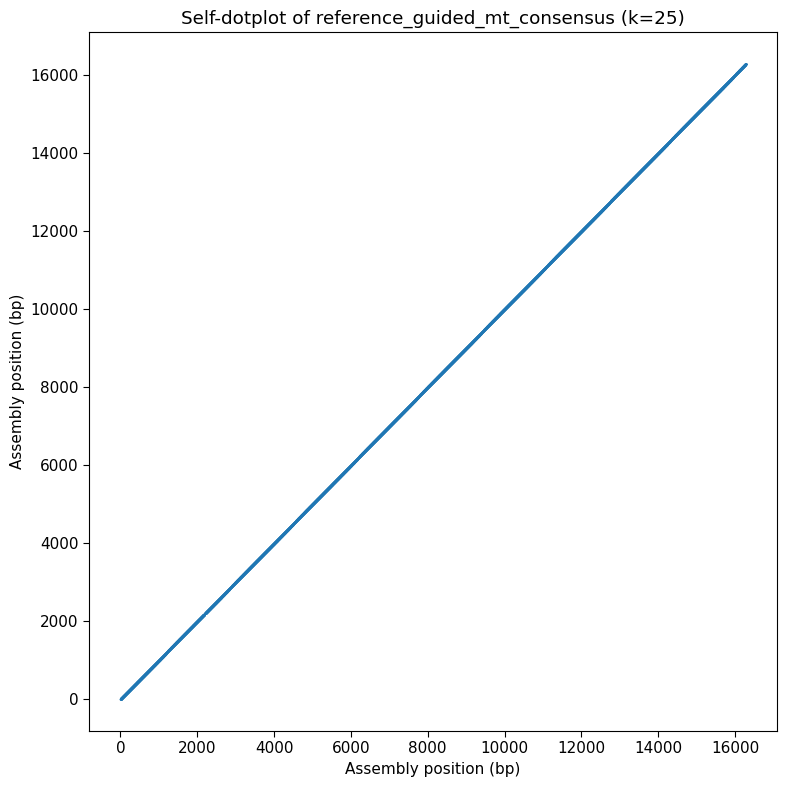

In [59]:
from Bio import SeqIO
import numpy as np
import matplotlib.pyplot as plt

# Input
assembly_file = OUTPUT_CONSENSUS if OUTPUT_CONSENSUS.exists() else REFERENCE_FILE
word_size = 25   # try 21, 25, 31; larger = cleaner, smaller = more sensitive
step = 1         # increase to 2 or 5 if you want faster but coarser results

# Read assembly
record = next(SeqIO.parse(str(assembly_file), "fasta"))
seq = str(record.seq).upper()
n = len(seq)

print(f"Assembly: {record.id}")
print(f"Length: {n} bp")
print(f"word_size: {word_size}")

# Index all k-mers in the sequence
kmer_positions = {}
for i in range(0, n - word_size + 1, step):
    kmer = seq[i:i+word_size]
    if "N" in kmer:
        continue
    kmer_positions.setdefault(kmer, []).append(i)

# Build dotplot points
x = []
y = []

for i in range(0, n - word_size + 1, step):
    kmer = seq[i:i+word_size]
    if "N" in kmer:
        continue
    matches = kmer_positions.get(kmer, [])
    for j in matches:
        x.append(i + 1)  # 1-based
        y.append(j + 1)

print(f"Dotplot points: {len(x)}")

# Plot
plt.figure(figsize=(8, 8))
plt.scatter(x, y, s=0.2)
plt.xlabel("Assembly position (bp)")
plt.ylabel("Assembly position (bp)")
plt.title(f"Self-dotplot of {record.id} (k={word_size})")
plt.tight_layout()
plt.show()

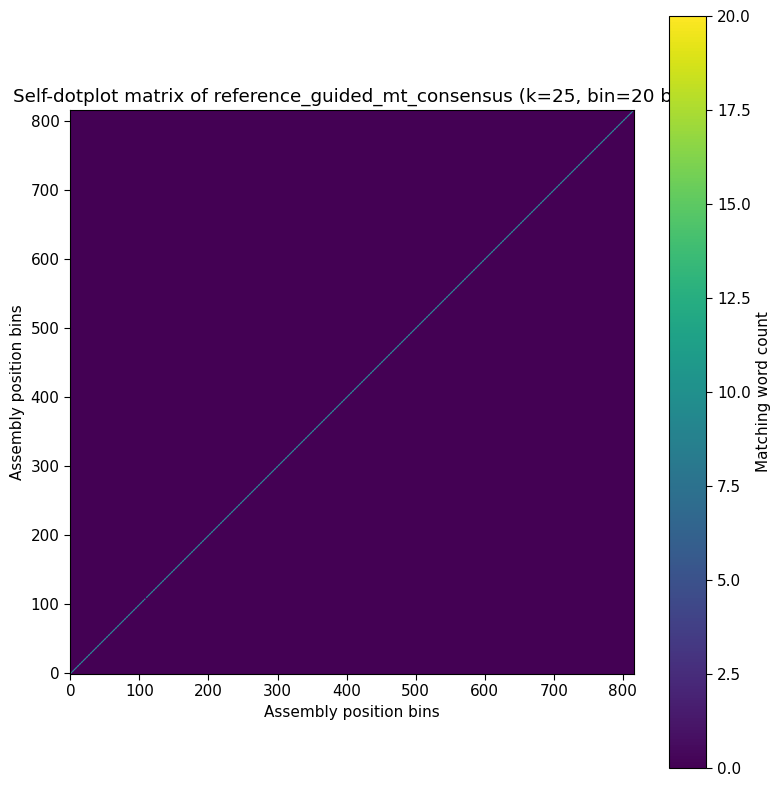

In [60]:
from Bio import SeqIO
import numpy as np
import matplotlib.pyplot as plt

assembly_file = OUTPUT_CONSENSUS if OUTPUT_CONSENSUS.exists() else REFERENCE_FILE
word_size = 25
bin_size = 20   # bp per pixel; smaller = higher resolution, larger = faster

record = next(SeqIO.parse(str(assembly_file), "fasta"))
seq = str(record.seq).upper()
n = len(seq)

nbins = (n + bin_size - 1) // bin_size
mat = np.zeros((nbins, nbins), dtype=np.uint16)

# index k-mers
kmer_positions = {}
for i in range(n - word_size + 1):
    kmer = seq[i:i+word_size]
    if "N" in kmer:
        continue
    kmer_positions.setdefault(kmer, []).append(i)

# fill matrix
for i in range(n - word_size + 1):
    kmer = seq[i:i+word_size]
    if "N" in kmer:
        continue
    xi = i // bin_size
    for j in kmer_positions[kmer]:
        yi = j // bin_size
        mat[yi, xi] += 1

plt.figure(figsize=(8, 8))
plt.imshow(mat, origin="lower", aspect="equal")
plt.xlabel("Assembly position bins")
plt.ylabel("Assembly position bins")
plt.title(f"Self-dotplot matrix of {record.id} (k={word_size}, bin={bin_size} bp)")
plt.colorbar(label="Matching word count")
plt.tight_layout()
plt.show()

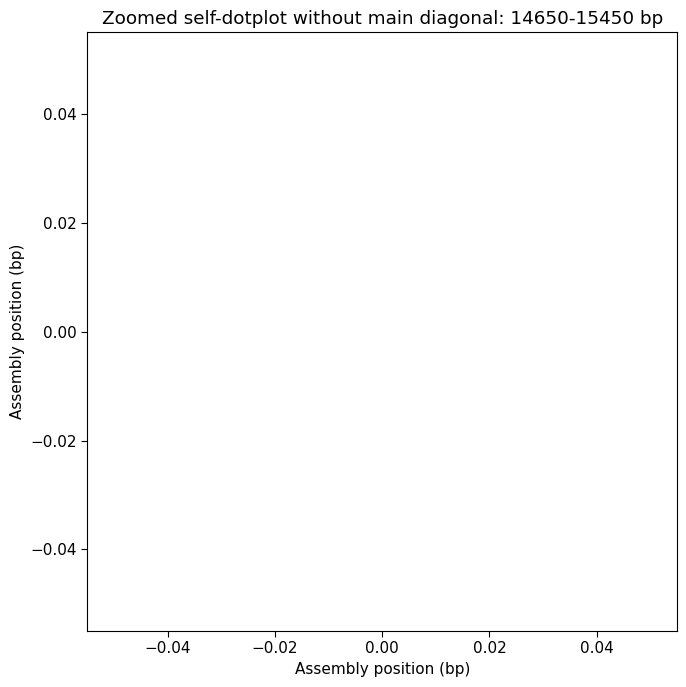

In [61]:
from Bio import SeqIO
import numpy as np
import matplotlib.pyplot as plt

assembly_file = OUTPUT_CONSENSUS if OUTPUT_CONSENSUS.exists() else REFERENCE_FILE
word_size = 25
start_bp = 14650
end_bp = 15450
diag_mask_bp = 40

record = next(SeqIO.parse(str(assembly_file), "fasta"))
seq = str(record.seq).upper()
zoom_width = end_bp - start_bp
if end_bp > len(seq):
    start_bp = max(1, len(seq) - zoom_width)
    end_bp = len(seq)
subseq = seq[start_bp-1:end_bp]
n = len(subseq)

kmer_positions = {}
for i in range(n - word_size + 1):
    kmer = subseq[i:i+word_size]
    if "N" in kmer:
        continue
    kmer_positions.setdefault(kmer, []).append(i)

x, y = [], []
for i in range(n - word_size + 1):
    kmer = subseq[i:i+word_size]
    if "N" in kmer:
        continue
    for j in kmer_positions.get(kmer, []):
        if abs(i - j) > diag_mask_bp:
            x.append(start_bp + i)
            y.append(start_bp + j)

plt.figure(figsize=(7, 7))
plt.scatter(x, y, s=4)
plt.xlabel("Assembly position (bp)")
plt.ylabel("Assembly position (bp)")
plt.title(f"Zoomed self-dotplot without main diagonal: {start_bp}-{end_bp} bp")
plt.tight_layout()
plt.show()

In [62]:
from Bio import SeqIO
from collections import defaultdict, Counter

assembly_file = OUTPUT_CONSENSUS if OUTPUT_CONSENSUS.exists() else REFERENCE_FILE
k = 100

record = next(SeqIO.parse(str(assembly_file), "fasta"))
seq = str(record.seq).upper()

kmers = defaultdict(list)
for i in range(len(seq) - k + 1):
    kmers[seq[i:i+k]].append(i + 1)

repeat_spacings = []
for positions in kmers.values():
    if len(positions) > 1:
        positions = sorted(positions)
        for a in range(len(positions)):
            for b in range(a + 1, len(positions)):
                repeat_spacings.append(positions[b] - positions[a])

spacing_counts = Counter(repeat_spacings)

print("Most common repeat spacings:")
for spacing, count in spacing_counts.most_common(20):
    print(f"{spacing} bp: {count} repeated k-mers")

Most common repeat spacings:


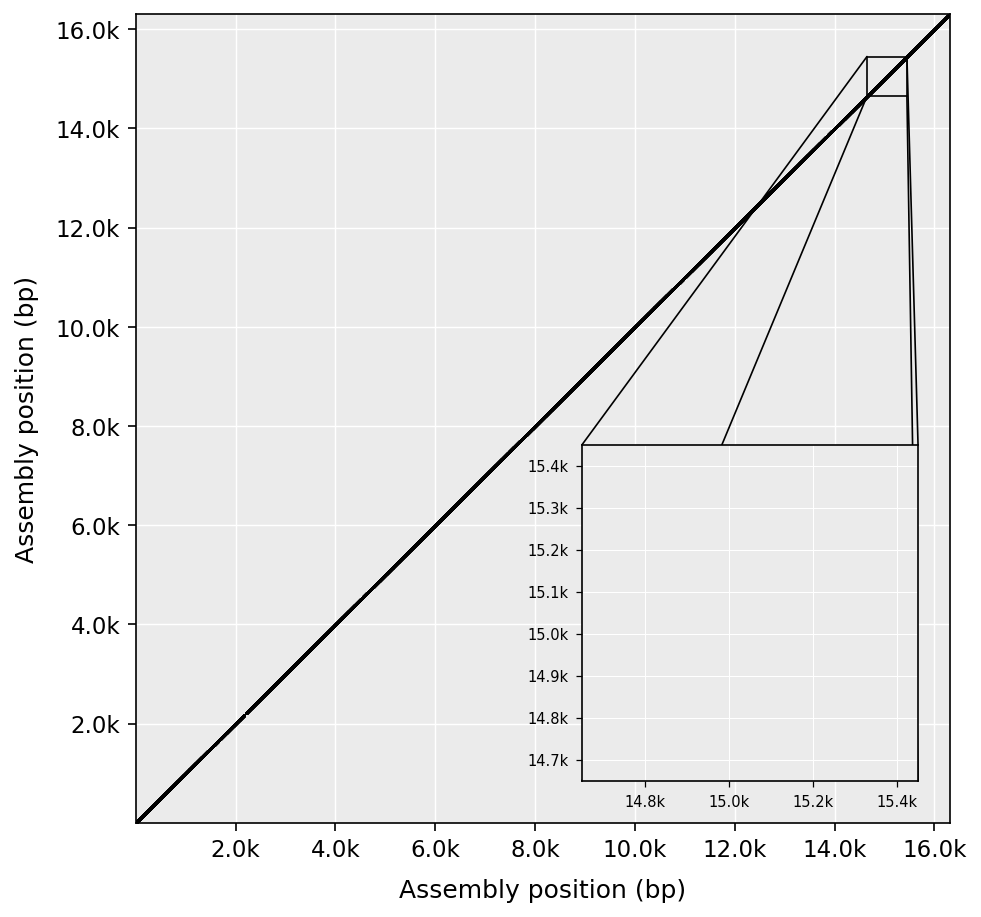

Saved: self_dotplot_with_inset.png


In [63]:
from Bio import SeqIO
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import FancyBboxPatch, Rectangle, ConnectionPatch

assembly_file = OUTPUT_CONSENSUS if OUTPUT_CONSENSUS.exists() else REFERENCE_FILE
word_size = 25
step = 1

# Zoom region
zoom_start = 14650
zoom_end = 15450
diag_mask_bp = 40

record = next(SeqIO.parse(str(assembly_file), "fasta"))
seq = str(record.seq).upper()
n = len(seq)
zoom_width = zoom_end - zoom_start
if zoom_end > n:
    zoom_start = max(1, n - zoom_width)
    zoom_end = n

# Index all k-mers
kmer_positions = {}
for i in range(0, n - word_size + 1, step):
    kmer = seq[i:i + word_size]
    if "N" in kmer:
        continue
    kmer_positions.setdefault(kmer, []).append(i)

# Collect all dotplot points
x_all, y_all = [], []
for i in range(0, n - word_size + 1, step):
    kmer = seq[i:i + word_size]
    if "N" in kmer:
        continue
    for j in kmer_positions.get(kmer, []):
        x_all.append(i + 1)
        y_all.append(j + 1)

x_all = np.array(x_all)
y_all = np.array(y_all)

# --- Publication-quality figure with inset ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})

fig, ax = plt.subplots(figsize=(7, 7), dpi=150)
ax.set_facecolor('#EBEBEB')
ax.grid(True, color='white', linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

# Main dotplot
ax.scatter(x_all, y_all, s=0.15, color='black', alpha=0.8, rasterized=True, zorder=2)
ax.set_xlabel("Assembly position (bp)", fontsize=12, labelpad=8)
ax.set_ylabel("Assembly position (bp)", fontsize=12, labelpad=8)
ax.set_xlim(1, n)
ax.set_ylim(1, n)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v/1000:.1f}k' if v >= 1000 else f'{v:.0f}'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v/1000:.1f}k' if v >= 1000 else f'{v:.0f}'))

# Draw zoom rectangle on the main plot
rect = Rectangle((zoom_start, zoom_start), zoom_end - zoom_start, zoom_end - zoom_start,
                 linewidth=0.8, edgecolor='black', facecolor='none', zorder=4)
ax.add_patch(rect)

# --- Create inset axes manually for precise control ---
# Position: [left, bottom, width, height] in figure fraction
# Place inset in lower-right area
ax_inset = fig.add_axes([0.55, 0.15, 0.32, 0.32], zorder=10)
ax_inset.set_facecolor('#EBEBEB')
ax_inset.grid(True, color='white', linewidth=0.5, zorder=0)
ax_inset.set_axisbelow(True)

# Filter points within zoom window, off the main diagonal
mask = (
    (x_all >= zoom_start) & (x_all <= zoom_end) &
    (y_all >= zoom_start) & (y_all <= zoom_end) &
    (np.abs(x_all - y_all) > diag_mask_bp)
)
ax_inset.scatter(x_all[mask], y_all[mask], s=1.5, color='black', alpha=0.9, rasterized=True, zorder=2)
ax_inset.set_xlim(zoom_start, zoom_end)
ax_inset.set_ylim(zoom_start, zoom_end)
ax_inset.tick_params(labelsize=7, width=0.6, length=3)
ax_inset.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v/1000:.1f}k'))
ax_inset.yaxis.set_major_formatter(ticker.FuncFormatter(lambda v, _: f'{v/1000:.1f}k'))
for spine in ax_inset.spines.values():
    spine.set_linewidth(0.8)
    spine.set_zorder(12)

# --- Draw 4 connector lines from zoom rectangle corners to inset corners ---
# Zoom rectangle corners in main-axes data coordinates
rect_corners = {
    'bottom_left':  (zoom_start, zoom_start),
    'bottom_right': (zoom_end,   zoom_start),
    'top_left':     (zoom_start, zoom_end),
    'top_right':    (zoom_end,   zoom_end),
}
# Inset corners in inset-axes fraction coordinates (0–1)
inset_corners = {
    'bottom_left':  (0, 0),
    'bottom_right': (1, 0),
    'top_left':     (0, 1),
    'top_right':    (1, 1),
}

for corner in ['bottom_left', 'bottom_right', 'top_left', 'top_right']:
    con = ConnectionPatch(
        xyA=rect_corners[corner], coordsA=ax.transData,
        xyB=inset_corners[corner], coordsB=ax_inset.transAxes,
        color='black', linewidth=0.8, zorder=5,
    )
    fig.add_artist(con)

fig.savefig("self_dotplot_with_inset.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved: self_dotplot_with_inset.png")

In [64]:
from collections import Counter, defaultdict
from pathlib import Path
import numpy as np
import pandas as pd
from Bio import SeqIO
from Bio import pairwise2

# -----------------------------
# Gap-rescue polish parameters
# -----------------------------
SEED_K = 10
SEED_STEP = 4
TOP_CANDIDATES = 40
ID_MIN = 0.78
COV_MIN = 0.70
SCORE_MARGIN = 5.0      # best score must exceed 2nd best by at least this to avoid repeat ambiguity
ROUNDS = 2
WRITE_WRAP = 80

# Output files
OUTPUT_CONSENSUS_RESCUED = BASE / "reference_guided_mt_consensus_gap_rescued.fasta"
OUTPUT_CONSENSUS_RESCUED_TABLE = BASE / "reference_guided_mt_consensus_gap_rescued_base_counts.csv"

# -----------------------------
# Helper functions
# -----------------------------
def _revcomp_local(seq):
    tab = str.maketrans("ACGTRYKMSWBDHVNacgtrykmswbdhvn", "TGCAYRMKSWVHDBNtgcayrmkswvhdbn")
    return seq.translate(tab)[::-1].upper()

def _build_seed_index(circular_seq, L, k):
    idx = defaultdict(list)
    if k < 1 or k > L:
        return idx
    # only starts in [0, L-1] to avoid duplicate circular starts
    for i in range(0, L):
        kmer = circular_seq[i:i+k]
        if len(kmer) < k or "N" in kmer:
            continue
        idx[kmer].append(i)
    return idx

def _candidate_starts(query, idx, L, k=10, step=4, topn=40):
    counter = Counter()
    if len(query) < k:
        return []
    for off in range(0, len(query) - k + 1, step):
        seed = query[off:off+k]
        if "N" in seed:
            continue
        for p in idx.get(seed, []):
            counter[(p - off) % L] += 1
    return [s for s, _ in counter.most_common(topn)]

def _alignment_stats_and_events(al_ref, al_q, begin, end, start0, L):
    # ref_pos in window at first aligned column
    ref_pos = sum(1 for c in al_ref[:begin] if c != "-")
    first_ref = None
    matches = mism = gaps = aligned_query_bases = 0
    events = []
    covered_positions = set()

    for ca, cb in zip(al_ref[begin:end], al_q[begin:end]):
        if cb != "-":
            aligned_query_bases += 1

        if ca != "-" and cb != "-":
            if first_ref is None:
                first_ref = ref_pos
            pos = (start0 + ref_pos) % L
            covered_positions.add(pos)
            if cb in "ACGT":
                events.append((pos, cb))
            if ca == cb:
                matches += 1
            else:
                mism += 1
        elif (ca == "-" and cb != "-") or (ca != "-" and cb == "-"):
            gaps += 1

        if ca != "-":
            ref_pos += 1

    if first_ref is None:
        return None

    identity = matches / max(1, matches + mism + gaps)
    qcov = aligned_query_bases / max(1, len(al_q.replace("-", "")))
    mapped_start = (start0 + first_ref) % L
    return {
        "mapped_start": mapped_start,
        "identity": identity,
        "qcov": qcov,
        "score_terms": (matches, mism, gaps),
        "events": events,
        "covered_positions": covered_positions,
    }

def _zero_intervals(mask):
    L = len(mask)
    out = []
    i = 0
    while i < L:
        if mask[i]:
            j = i
            while j < L and mask[j]:
                j += 1
            out.append((i + 1, j))  # 1-based inclusive
            i = j
        else:
            i += 1
    return out

# -----------------------------
# Read current consensus and evidence
# -----------------------------
record = next(SeqIO.parse(str(OUTPUT_CONSENSUS), "fasta"))
current_consensus = str(record.seq).upper()
L = len(current_consensus)

if L != reference_len:
    raise ValueError(f"Consensus length ({L}) != reference_len ({reference_len}).")

# Start from existing base evidence if available; else empty
if "base_counts" in globals() and len(base_counts) == L:
    counts = [Counter(c) for c in base_counts]
else:
    counts = [Counter() for _ in range(L)]

# Read pool: use all records if available (includes duplicate IDs), otherwise unique-by-ID reads
if "all_records" in globals() and len(all_records) > 0:
    read_pool = [seq.upper() for _, seq in all_records if seq]
else:
    read_pool = [rec["sequence"].upper() for rec in unique_by_id.values() if rec["sequence"]]

print(f"Initial consensus length: {L}")
print(f"Read pool size used for rescue: {len(read_pool)}")

depth_before = np.array([sum(c.values()) for c in counts], dtype=int)
zero_before = depth_before == 0
print(f"Zero-depth positions before rescue: {int(zero_before.sum())}")
print("Zero-depth intervals before rescue (first 10):", _zero_intervals(zero_before)[:10])

# -----------------------------
# Iterative rescue rounds
# -----------------------------
consensus = list(current_consensus)

for rnd in range(1, ROUNDS + 1):
    depth = np.array([sum(c.values()) for c in counts], dtype=int)
    unresolved = (depth == 0)

    if unresolved.sum() == 0:
        print(f"Round {rnd}: no unresolved positions left; stopping.")
        break

    # Build circular scaffold for seeding; replace N by reference base only for indexing/alignment scaffold
    scaffold = "".join(reference_seq[i] if consensus[i] == "N" else consensus[i] for i in range(L))
    circular_scaffold = scaffold + scaffold
    seed_index = _build_seed_index(circular_scaffold, L, SEED_K)

    accepted_reads = 0
    added_bases = 0

    for s in read_pool:
        if not s:
            continue

        candidates = []
        for orient_name, q in (("forward", s), ("reverse", _revcomp_local(s))):
            starts = _candidate_starts(q, seed_index, L, k=SEED_K, step=SEED_STEP, topn=TOP_CANDIDATES)
            for st in starts:
                window = circular_scaffold[st:st + len(q) + 60]
                alns = pairwise2.align.localms(window, q, 2, -1, -2, -0.5, one_alignment_only=True)
                if not alns:
                    continue

                al_ref, al_q, score, begin, end = alns[0]
                stats = _alignment_stats_and_events(al_ref, al_q, begin, end, st, L)
                if stats is None:
                    continue
                if stats["identity"] < ID_MIN or stats["qcov"] < COV_MIN:
                    continue

                covered_unresolved = sum(1 for p in stats["covered_positions"] if unresolved[p])
                if covered_unresolved == 0:
                    continue

                candidates.append({
                    "score": float(score),
                    "identity": stats["identity"],
                    "qcov": stats["qcov"],
                    "covered_unresolved": covered_unresolved,
                    "events": stats["events"],
                })

        if not candidates:
            continue

        candidates.sort(key=lambda d: (d["score"], d["identity"], d["qcov"], d["covered_unresolved"]), reverse=True)
        best = candidates[0]
        second_score = candidates[1]["score"] if len(candidates) > 1 else None

        # Ambiguity filter in repetitive regions
        if second_score is not None and (best["score"] - second_score) < SCORE_MARGIN:
            continue

        # Add evidence only to currently unresolved positions to avoid changing already-supported bases
        used_any = False
        for pos, base in best["events"]:
            if unresolved[pos]:
                counts[pos][base] += 1
                added_bases += 1
                used_any = True
        if used_any:
            accepted_reads += 1

    # Update consensus only where unresolved and now supported
    changed = 0
    for i in range(L):
        if unresolved[i] and sum(counts[i].values()) > 0:
            maxc = max(counts[i].values())
            tied = sorted([b for b, c in counts[i].items() if c == maxc])
            new_base = reference_seq[i] if reference_seq[i] in tied else tied[0]
            if consensus[i] != new_base:
                consensus[i] = new_base
                changed += 1

    depth_after_round = np.array([sum(c.values()) for c in counts], dtype=int)
    unresolved_after = (depth_after_round == 0).sum()

    print(f"Round {rnd}: accepted_reads={accepted_reads}, added_bases={added_bases}, changed_positions={changed}, unresolved_left={int(unresolved_after)}")

# -----------------------------
# Write polished outputs
# -----------------------------
rescued_seq = "".join(consensus)
rows = []
for i, c in enumerate(counts):
    total = sum(c.values())
    base = rescued_seq[i]
    rows.append({
        "position_1based": i + 1,
        "reference_base": reference_seq[i],
        "consensus_base": base,
        "depth": total,
        "A": c.get("A", 0),
        "C": c.get("C", 0),
        "G": c.get("G", 0),
        "T": c.get("T", 0),
    })

with open(OUTPUT_CONSENSUS_RESCUED, "w") as h:
    covered = sum(1 for b in rescued_seq if b != "N")
    h.write(f">reference_guided_mt_consensus_gap_rescued length={L} covered_bp={covered} reference={reference_id}\n")
    for i in range(0, L, WRITE_WRAP):
        h.write(rescued_seq[i:i + WRITE_WRAP] + "\n")

pd.DataFrame(rows).to_csv(OUTPUT_CONSENSUS_RESCUED_TABLE, index=False)

depth_final = np.array([r["depth"] for r in rows], dtype=int)
zero_final = depth_final == 0

print("\nRescue complete.")
print(f"Zero-depth positions after rescue: {int(zero_final.sum())}")
print("Zero-depth intervals after rescue (first 10):", _zero_intervals(zero_final)[:10])
print("Wrote:")
print(" -", OUTPUT_CONSENSUS_RESCUED)
print(" -", OUTPUT_CONSENSUS_RESCUED_TABLE)

Initial consensus length: 16304
Read pool size used for rescue: 7836
Zero-depth positions before rescue: 1
Zero-depth intervals before rescue (first 10): [(2203, 2203)]
Round 1: accepted_reads=0, added_bases=0, changed_positions=0, unresolved_left=1
Round 2: accepted_reads=0, added_bases=0, changed_positions=0, unresolved_left=1

Rescue complete.
Zero-depth positions after rescue: 1
Zero-depth intervals after rescue (first 10): [(2203, 2203)]
Wrote:
 - reference_guided_mt_consensus_gap_rescued.fasta
 - reference_guided_mt_consensus_gap_rescued_base_counts.csv


In [65]:
# Print zero-coverage sequences with custom flanking region
# Change this number:
FLANK_BP = 50

from pathlib import Path
import pandas as pd

# Uses existing notebook variables:
# depth, reference_seq, reference_len, BASE

ref = reference_seq.upper()
L = reference_len

def circular_slice_1based(seq, start_1based, end_1based):
    """Return circular sequence from start to end, both 1-based inclusive."""
    start0 = (start_1based - 1) % L
    end0 = (end_1based - 1) % L

    if start0 <= end0:
        return seq[start0:end0 + 1]
    else:
        return seq[start0:] + seq[:end0 + 1]

# Re-detect zero-coverage intervals
zero_intervals = []
i = 0
while i < L:
    if depth[i] == 0:
        j = i
        while j < L and depth[j] == 0:
            j += 1
        zero_intervals.append((i + 1, j))  # 1-based inclusive
        i = j
    else:
        i += 1

# Merge circular zero interval if gap crosses origin
if len(zero_intervals) > 1:
    first_start, first_end = zero_intervals[0]
    last_start, last_end = zero_intervals[-1]

    if first_start == 1 and last_end == L:
        merged = (last_start, first_end)
        zero_intervals = [merged] + zero_intervals[1:-1]

rows = []
fasta_lines = []

print(f"Reference length: {L} bp")
print(f"Flanking region: {FLANK_BP} bp")
print(f"Zero-coverage intervals found: {len(zero_intervals)}\n")

for idx, (zero_start, zero_end) in enumerate(zero_intervals, start=1):
    if zero_start <= zero_end:
        zero_len = zero_end - zero_start + 1
    else:
        zero_len = (L - zero_start + 1) + zero_end

    flank_start = ((zero_start - FLANK_BP - 1) % L) + 1
    flank_end = ((zero_end + FLANK_BP - 1) % L) + 1

    zero_seq = circular_slice_1based(ref, zero_start, zero_end)
    flank_seq = circular_slice_1based(ref, flank_start, flank_end)

    header_zero = f"zero_coverage_{idx}|zero={zero_start}-{zero_end}|len={zero_len}"
    header_flank = (
        f"zero_coverage_{idx}_with_{FLANK_BP}bp_flanks|"
        f"region={flank_start}-{flank_end}|zero={zero_start}-{zero_end}|zero_len={zero_len}"
    )

    print("=" * 80)
    print(header_zero)
    print(zero_seq)
    print()
    print(header_flank)
    print(flank_seq)
    print()

    fasta_lines.append(f">{header_zero}\n")
    fasta_lines.append(zero_seq + "\n")
    fasta_lines.append(f">{header_flank}\n")
    fasta_lines.append(flank_seq + "\n")

    rows.append({
        "zero_interval_number": idx,
        "zero_start_1based": zero_start,
        "zero_end_1based": zero_end,
        "zero_length_bp": zero_len,
        "flank_bp_each_side": FLANK_BP,
        "flanked_region_start_1based": flank_start,
        "flanked_region_end_1based": flank_end,
        "zero_sequence": zero_seq,
        "flanked_sequence": flank_seq,
    })

zero_df = pd.DataFrame(rows)

output_fasta = BASE / f"zero_coverage_sequences_with_{FLANK_BP}bp_flanks.fasta"
output_csv = BASE / f"zero_coverage_sequences_with_{FLANK_BP}bp_flanks.csv"

with open(output_fasta, "w") as handle:
    handle.writelines(fasta_lines)

zero_df.to_csv(output_csv, index=False)

print("=" * 80)
print("Saved:")
print(" -", output_fasta)
print(" -", output_csv)

zero_df

Reference length: 16304 bp
Flanking region: 50 bp
Zero-coverage intervals found: 1

zero_coverage_1|zero=2203-2203|len=1
T

zero_coverage_1_with_50bp_flanks|region=2153-2253|zero=2203-2203|zero_len=1
ACGAGAAGACCCTATGGAGCTTAAATTATATAACTTATCTATTTAATTTATTAAACCTAATGGCCCAAAAACTATAGTATAAGTTTGAAATTTCGGTTGGG

Saved:
 - zero_coverage_sequences_with_50bp_flanks.fasta
 - zero_coverage_sequences_with_50bp_flanks.csv


,zero_interval_number,zero_start_1based,zero_end_1based,zero_length_bp,flank_bp_each_side,flanked_region_start_1based,flanked_region_end_1based,zero_sequence,flanked_sequence
0,1,2203,2203,1,50,2153,2253,T,ACGAGAAGACCCTATGGAGCTTAAATTATATAACTTATCTATTTAA...
